In [15]:
#imports 

from torchvision import transforms, models, datasets

# Other imports as necessary

import torch 
import torch.optim as optim 
import torch.nn as nn
import torchmetrics
import matplotlib.pyplot as plt 
from torch.utils.data import DataLoader


from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np




In [16]:
# Getting and transforming the images. 

height = 64
width = 64
batch_size = 32

transform = transforms.Compose([
    transforms.Resize((height, width)),
    transforms.Grayscale(num_output_channels=1), 
    transforms.ToTensor(),
])


train_dataset = datasets.ImageFolder("data/train", transform=transform)
test_dataset = datasets.ImageFolder("data/test", transform=transform)
print(f"Number of training samples: {len(train_dataset)}")
print(f"Shape of a sample: {train_dataset[0][0].shape}")


Number of training samples: 2172
Shape of a sample: torch.Size([1, 64, 64])


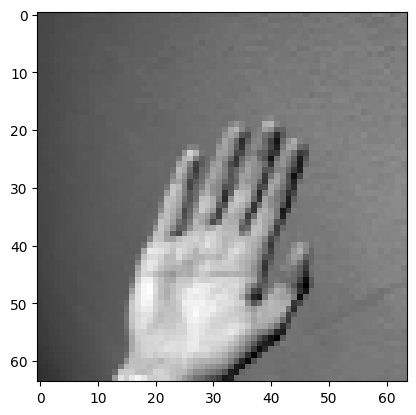

Label of the first image: paper
Highest pixel value in the first image: 0.9372549057006836
Lowest pixel value in the first image: 0.35686275362968445


In [17]:
#Displaying the first image in the training set.
x_sample = train_dataset[0][0].reshape(height, width)
plt.imshow(x_sample, cmap='gray')
plt.show()
print(f"Label of the first image: {train_dataset.classes[train_dataset[0][1]]}")

print(f"Highest pixel value in the first image: {torch.max(train_dataset[0][0])}")
print(f"Lowest pixel value in the first image: {torch.min(train_dataset[0][0])}")


In [18]:
#Defining the model.
torch.manual_seed(42)

n_features = height * width
n_labels = len(train_dataset.classes)
# print(f"Number of features: {n_features}")
# print(f"Number of labels: {n_labels}")

model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(n_features, 100),
    nn.ReLU(),
    nn.Linear(100, 60),
    nn.ReLU(),
    nn.Linear(60, n_labels) #the output has 10 neurons, corresponding to the 10 possible classes. 
)

In [19]:
#creating the dataloaders. 

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 100
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for images, labels in train_loader:
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss:.4f}")

Epoch 1/100, Loss: 75.6907
Epoch 2/100, Loss: 73.8443
Epoch 3/100, Loss: 71.9328
Epoch 4/100, Loss: 71.8056
Epoch 5/100, Loss: 70.0057
Epoch 6/100, Loss: 69.0820
Epoch 7/100, Loss: 65.0197
Epoch 8/100, Loss: 63.5270
Epoch 9/100, Loss: 61.0928
Epoch 10/100, Loss: 61.2727
Epoch 11/100, Loss: 62.3440
Epoch 12/100, Loss: 62.3117
Epoch 13/100, Loss: 58.3549
Epoch 14/100, Loss: 58.5153
Epoch 15/100, Loss: 57.3746
Epoch 16/100, Loss: 57.2676
Epoch 17/100, Loss: 56.4659
Epoch 18/100, Loss: 55.6799
Epoch 19/100, Loss: 56.0458
Epoch 20/100, Loss: 58.5134
Epoch 21/100, Loss: 64.1498
Epoch 22/100, Loss: 57.8873
Epoch 23/100, Loss: 55.4872
Epoch 24/100, Loss: 56.0800
Epoch 25/100, Loss: 54.9748
Epoch 26/100, Loss: 54.3235
Epoch 27/100, Loss: 53.9882
Epoch 28/100, Loss: 54.6470
Epoch 29/100, Loss: 50.7046
Epoch 30/100, Loss: 49.9837
Epoch 31/100, Loss: 49.4363
Epoch 32/100, Loss: 49.3732
Epoch 33/100, Loss: 48.2646
Epoch 34/100, Loss: 47.4913
Epoch 35/100, Loss: 49.0753
Epoch 36/100, Loss: 47.7349
E

Confusion Matrix:
[[118  28  36]
 [ 13 162   7]
 [ 14  17 150]]

Classification Report:
              precision    recall  f1-score   support

       paper       0.81      0.65      0.72       182
        rock       0.78      0.89      0.83       182
    scissors       0.78      0.83      0.80       181

    accuracy                           0.79       545
   macro avg       0.79      0.79      0.79       545
weighted avg       0.79      0.79      0.79       545



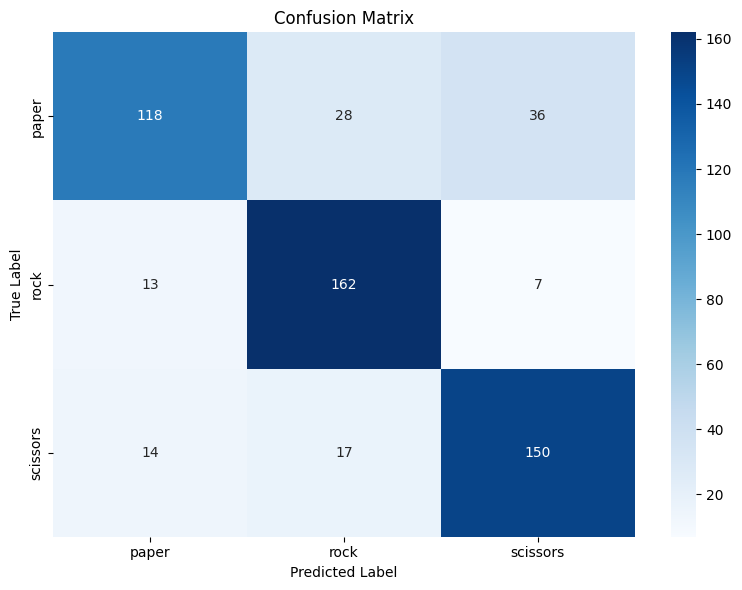


Test Accuracy: 0.7890


In [20]:
# Evaluate the model on test data
model.eval()
all_preds = []
all_labels = []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Generate confusion matrix
cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:")
print(cm)

# Print classification report
class_names = test_dataset.classes  # ['paper', 'rock', 'scissors']
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

# Calculate and print accuracy
accuracy = (np.array(all_preds) == np.array(all_labels)).mean()
print(f"\nTest Accuracy: {accuracy:.4f}")

